# Test Signature & Cachet PDF — Debug complet

Ce notebook permet de :
1. **Inspecter** le texte extrait du PDF (ce que pymupdf voit)
2. **Détecter** la zone signature/cachet sur la **dernière page uniquement**
3. **Visualiser** la zone détectée avec des rectangles colorés
4. **Appliquer** signature + cachet superposés + remplir 'Fait à'
5. **Afficher** le résultat avant/après

**Logique de détection :**
- Recherche uniquement sur la **dernière page** (évite les faux positifs du corps du texte)
- Token matching en **sous-chaîne** : `"signature" in "signatureet"` → True
- La ligne avec le **meilleur score combiné** (sig + cac tokens) gagne
- En cas d'égalité, la ligne **la plus basse** dans la page est préférée
- Cachet + signature sont placés **l'un sur l'autre** (superposés) sous le mot-clé

**Structure attendue :**
```
rd/signature/
  assets/
    signature.jpg   ← image de la signature
    cachet.png      ← image du cachet
  input/
    document.pdf    ← le PDF à tester
  output/           ← PDF signé généré ici
```

In [31]:
!pip install pymupdf pillow matplotlib -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Configuration

In [32]:
import fitz
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

BASE       = Path(".")
PDF_INPUT  = BASE / "input" / "RC AO N¯02-2025-DRCADT.pdf"   # ← change ici si besoin
PDF_OUTPUT = BASE / "output" / "signé.pdf"
SIGNATURE  = BASE / "assets" / "signature.jpg"
CACHET     = BASE / "assets" / "cachet.png"

# Lieu et date à insérer dans 'Fait à …, le …'
LIEU     = "Casablanca"
DATE_STR = "16/03/2026"

# Dimensions des images en points PDF (1pt = 1/72 pouce)
SIG_W, SIG_H   = 120, 50    # signature
CAC_W, CAC_H   = 100, 100   # cachet
SIG_MX, SIG_MY = 50, 40     # marges fallback signature (depuis bord droit/bas)
CAC_MX, CAC_MY = 50, 40     # marges fallback cachet    (depuis bord gauche/bas)

for d in [BASE/"input", BASE/"output", BASE/"assets"]:
    d.mkdir(parents=True, exist_ok=True)

print("PDF input  :", PDF_INPUT.exists(), f"({PDF_INPUT})")
print("Signature  :", SIGNATURE.exists())
print("Cachet     :", CACHET.exists())

PDF input  : True (input\RC AO N¯02-2025-DRCADT.pdf)
Signature  : True
Cachet     : True


## 1. Inspection du texte extrait — TOUTES les pages

Affiche tout ce que pymupdf lit dans le document, avec les coordonnées y.  
Utile pour voir si un mot-clé est présent dans le corps du texte (faux positif potentiel).

In [33]:
doc = fitz.open(str(PDF_INPUT))
print(f"PDF : {len(doc)} page(s)\n")

for page_num, page in enumerate(doc):
    lines_on_page = []
    for block in page.get_text("dict")["blocks"]:
        for line in block.get("lines", []):
            spans = line.get("spans", [])
            if not spans:
                continue
            text = "".join(s["text"] for s in spans).strip()
            if text:
                bbox = fitz.Rect(
                    min(s["bbox"][0] for s in spans),
                    min(s["bbox"][1] for s in spans),
                    max(s["bbox"][2] for s in spans),
                    max(s["bbox"][3] for s in spans),
                )
                lines_on_page.append((text, bbox))

    if lines_on_page:
        print(f"── Page {page_num+1} ({page.rect.width:.0f}×{page.rect.height:.0f}pt) ──")
        for text, bbox in lines_on_page:
            print(f"  y={bbox.y0:6.1f}  [{bbox.x0:.0f},{bbox.y0:.0f},{bbox.x1:.0f},{bbox.y1:.0f}]  {text!r}")
        print()

doc.close()

PDF : 32 page(s)

── Page 1 (595×842pt) ──
  y= 814.9  [75,815,544,826]  'RC AO N°02/2025/DRCADT                                                              - Règlement de consultation-                  Page 1'
  y= 164.0  [147,164,476,180]  'DIRECTION REGIONALE DE DRAA-TAFILALET'
  y= 217.2  [102,217,522,233]  'APPEL D’OFFRES OUVERT NATIONAL SUR OFFRES DE PRIX'
  y= 245.8  [235,246,386,263]  'N° 02/2025/DRCADT'
  y= 475.0  [252,475,372,491]  '(EN DEUX LOTS)'
  y= 528.1  [190,528,425,544]  'REGLEMENT DE CONSULTATION'
  y= 601.0  [57,601,557,615]  "En application de l'alinéa 2, paragraphe 1 du I) de l'article 19 et paragraphe 1 de l'article 20 et"
  y= 617.2  [57,617,557,631]  'l’alinéa b), du paragraphe 3 de l’article 20 du décret n° 2-22-431 du 15 Chaabane 1444 (08 mars'
  y= 633.4  [57,633,233,647]  '2023) relatif aux marchés publics.'
  y= 369.2  [115,369,504,388]  'Organisation des sessions de formation au profit des'
  y= 387.9  [163,388,459,407]  'agriculteurs de la Région Draa-

## 2. Détection des zones sur chaque page

**Logique complète :**

| Page | "Fait à" présent | Action |
|------|-----------------|--------|
| N'importe laquelle | ✅ Oui | Cherche une zone sig/cac **en dessous** de "Fait à" → si trouvée, place sig+cac là |
| Dernière page | ❌ Non | Cherche une zone sig/cac par mots-clés sur toute la page → place sig+cac |
| Dernière page | ❌ Non + aucun mot-clé | Fallback positions fixes (bas-droite / bas-gauche) |

**Pourquoi cette logique ?**  
Les mots-clés "signature", "cachet", "concurrent" peuvent apparaître partout dans le corps du texte.  
Sur une page avec "Fait à", on ne cherche les mots-clés **qu'en dessous** de cette ligne — là où se trouve réellement la zone de signature.

In [34]:
SIG_TOKENS = ["signature", "signataire", "soumissionnaire"]
CAC_TOKENS = ["cachet", "concurrent"]
ALL_TOKENS = SIG_TOKENS + CAC_TOKENS


def extract_lines(page):
    lines = []
    for block in page.get_text("dict")["blocks"]:
        for line in block.get("lines", []):
            spans = line.get("spans", [])
            if not spans:
                continue
            text = "".join(s["text"] for s in spans).lower()
            rect = fitz.Rect(
                min(s["bbox"][0] for s in spans), min(s["bbox"][1] for s in spans),
                max(s["bbox"][2] for s in spans), max(s["bbox"][3] for s in spans),
            )
            lines.append((text, rect))
    return lines


def score_line(text, tokens):
    return sum(1 for t in tokens if t in text)


def matched_tokens(text, tokens):
    return [t for t in tokens if t in text]


def find_zone_below(page, below_y):
    """Cherche zone sig/cac uniquement sous below_y (bas de la ligne 'Fait à')."""
    lines = extract_lines(page)
    best = None
    for text, rect in lines:
        if rect.y0 <= below_y:
            continue
        s = score_line(text, ALL_TOKENS)
        if s > 0:
            if best is None or s > best[0] or (s == best[0] and rect.y0 > best[1]):
                best = (s, rect.y0, rect, text)
    if best is None:
        return None, None, [], []
    _, _, rect, text = best
    return rect, text, matched_tokens(text, SIG_TOKENS), matched_tokens(text, CAC_TOKENS)


def find_zone_last_page(page):
    """Zone sig/cac sur la dernière page (toute la page)."""
    lines = extract_lines(page)
    best = None
    for text, rect in lines:
        s = score_line(text, ALL_TOKENS)
        if s > 0:
            if best is None or s > best[0] or (s == best[0] and rect.y0 > best[1]):
                best = (s, rect.y0, rect, text)
    if best is None:
        return None, None, [], []
    _, _, rect, text = best
    return rect, text, matched_tokens(text, SIG_TOKENS), matched_tokens(text, CAC_TOKENS)


def find_fait_a_with_detail(page):
    for block in page.get_text("dict")["blocks"]:
        for line in block.get("lines", []):
            spans = line.get("spans", [])
            full = "".join(s["text"] for s in spans)
            if "Fait" in full and ("\u00e0" in full or "ait a" in full.lower()):
                if spans:
                    kw = "à" if "\u00e0" in full else "a"
                    return fitz.Rect(spans[0]["bbox"]), spans[0]["size"], full.strip(), kw
    return None, 10.0, None, None


def find_fait_a(page):
    r, fs, _, _ = find_fait_a_with_detail(page)
    return r, fs


# ── Analyse complète du document ─────────────────────────────
doc = fitz.open(str(PDF_INPUT))
n_pages = len(doc)
print(f"PDF : {n_pages} page(s)\n")
print("=" * 70)

for i, page in enumerate(doc):
    is_last = (i == n_pages - 1)
    fait_rect, _, fait_text, fait_kw = find_fait_a_with_detail(page)

    if fait_rect is not None:
        # Page avec "Fait à" → cherche sig/cac EN DESSOUS uniquement
        zone_rect, zone_text, sig_m, cac_m = find_zone_below(page, fait_rect.y1)
        print(f"Page {i+1} — 'Fait à' détecté :")
        print(f"  Texte lu  : {fait_text!r}")
        print(f"  Keyword   : 'Fait {fait_kw}'")
        if zone_rect:
            print(f"  ✅ Zone sig/cac trouvée EN DESSOUS :")
            print(f"     Texte   : {zone_text!r}")
            print(f"     Tokens sig : {sig_m if sig_m else '(aucun)'}")
            print(f"     Tokens cac : {cac_m if cac_m else '(aucun)'}")
            print(f"     → Cachet + Signature seront placés ici")
        else:
            print(f"  ➖ Aucune zone sig/cac trouvée sous 'Fait à' → pas de signature sur cette page")

    elif is_last:
        # Dernière page sans "Fait à" → recherche par mots-clés toute la page
        zone_rect, zone_text, sig_m, cac_m = find_zone_last_page(page)
        print(f"Page {i+1} (dernière) — pas de 'Fait à' :")
        if zone_rect:
            print(f"  ✅ Zone sig/cac détectée par mots-clés :")
            print(f"     Texte   : {zone_text!r}")
            print(f"     Tokens sig : {sig_m if sig_m else '(aucun)'}")
            print(f"     Tokens cac : {cac_m if cac_m else '(aucun)'}")
            print(f"     → Cachet + Signature seront placés ici")
        else:
            print(f"  ❌ Aucun mot-clé → fallback positions fixes (bas-droite / bas-gauche)")

    print()

doc.close()

PDF : 32 page(s)




























Page 28 — 'Fait à' détecté :
  Texte lu  : 'Fait à...…....., le......…...............'
  Keyword   : 'Fait à'
  ✅ Zone sig/cac trouvée EN DESSOUS :
     Texte   : 'signature et cachet du concurrent  '
     Tokens sig : ['signature']
     Tokens cac : ['cachet', 'concurrent']
     → Cachet + Signature seront placés ici



Page 31 — 'Fait à' détecté :
  Texte lu  : 'Fait à....................., le....................'
  Keyword   : 'Fait à'
  ✅ Zone sig/cac trouvée EN DESSOUS :
     Texte   : 'signature et cachet du concurrent  '
     Tokens sig : ['signature']
     Tokens cac : ['cachet', 'concurrent']
     → Cachet + Signature seront placés ici

Page 32 — 'Fait à' détecté :
  Texte lu  : 'Fait à ………………le …………………..'
  Keyword   : 'Fait à'
  ✅ Zone sig/cac trouvée EN DESSOUS :
     Texte   : '(signature et cachet du concurrent) '
     Tokens sig : ['signature']
     Tokens cac : ['cachet', 'concurrent']
     → Cachet + Signature seront placés 

## 3. Debug — Toutes les lignes candidates sur la dernière page

Affiche le score de chaque ligne sur la dernière page pour comprendre pourquoi
une ligne est choisie (ou pas). Trié par score décroissant puis y0 décroissant.

In [35]:
doc = fitz.open(str(PDF_INPUT))
last = doc[len(doc) - 1]
lines = extract_lines(last)

print(f"Dernière page ({last.rect.width:.0f}×{last.rect.height:.0f}pt) — scores de toutes les lignes :")
print()

candidates = []
for text, rect in lines:
    s_score = score_line(text, SIG_TOKENS)
    c_score = score_line(text, CAC_TOKENS)
    total   = s_score + c_score
    if total > 0:
        candidates.append((total, rect.y0, s_score, c_score, text, rect))

if candidates:
    candidates.sort(key=lambda x: (-x[0], -x[1]))  # score desc, y0 desc
    print(f"{'Score':>5}  {'sig':>3}  {'cac':>3}  {'y0':>6}  Texte")
    print("-" * 70)
    for total, y0, s, c, text, rect in candidates:
        marker = " ← SÉLECTIONNÉE" if (total, y0) == (candidates[0][0], candidates[0][1]) else ""
        print(f"  {total:3d}   {s:3d}   {c:3d}  {y0:6.1f}  {text!r}{marker}")
else:
    print("Aucune ligne avec token sig/cac trouvée sur la dernière page.")
    print("→ Le fallback (positions fixes) sera utilisé.")

doc.close()

Dernière page (595×842pt) — scores de toutes les lignes :

Score  sig  cac      y0  Texte
----------------------------------------------------------------------
    3     1     2   667.3  '(signature et cachet du concurrent) ' ← SÉLECTIONNÉE
    1     0     1   331.4  'le concurrent dressera la liste complète du matériel de l’entreprise en distinguant : '
    1     0     1    60.6  'note sur les moyens humains et techniques du concurrent (*) '


## 4. Visualisation — zone détectée + placement prévu

- 🟣 **Violet** = ligne détectée (header)
- 🔵 **Bleu pointillé** = où la signature sera placée
- 🔴 **Rouge pointillé** = où le cachet sera placé (superposé avec la signature)
- 🟢 **Vert** = ligne 'Fait à' détectée

C:\Users\eeljazouli\AppData\Local\Temp\ipykernel_39552\1339853045.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


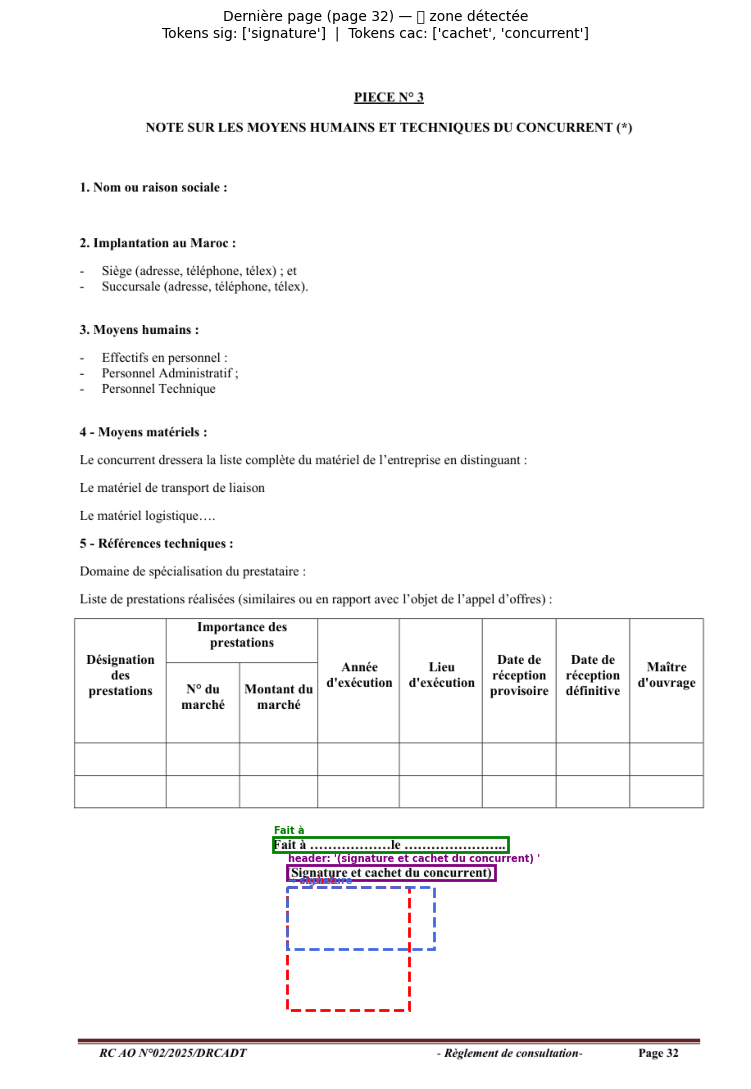

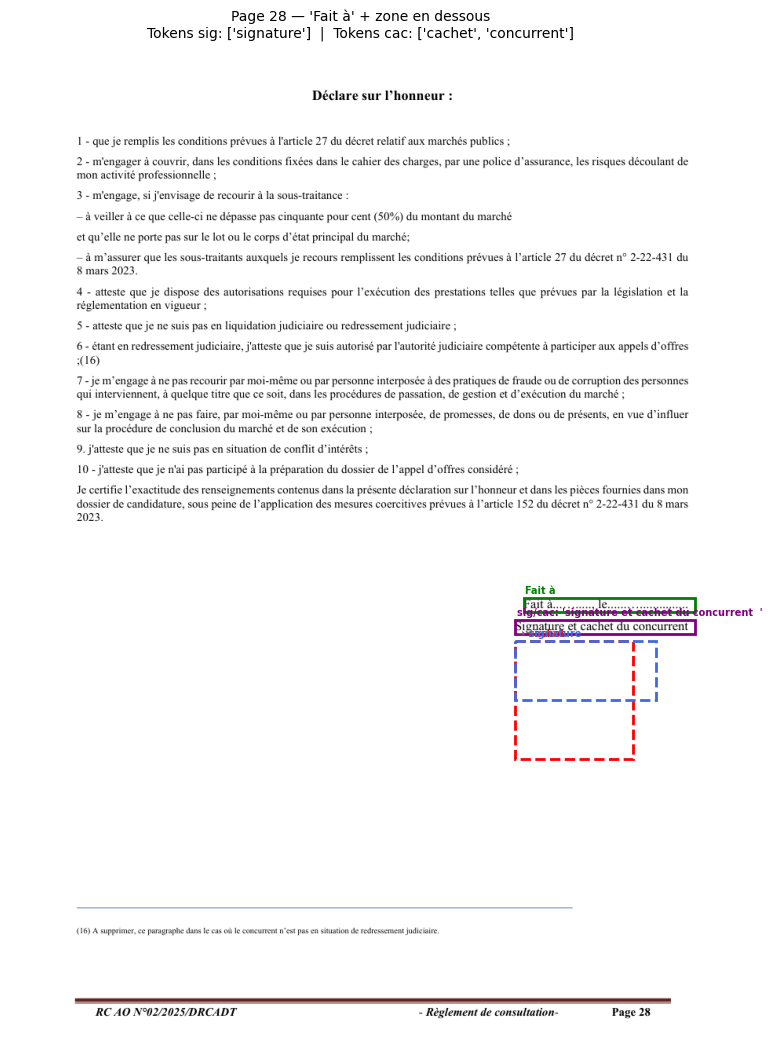

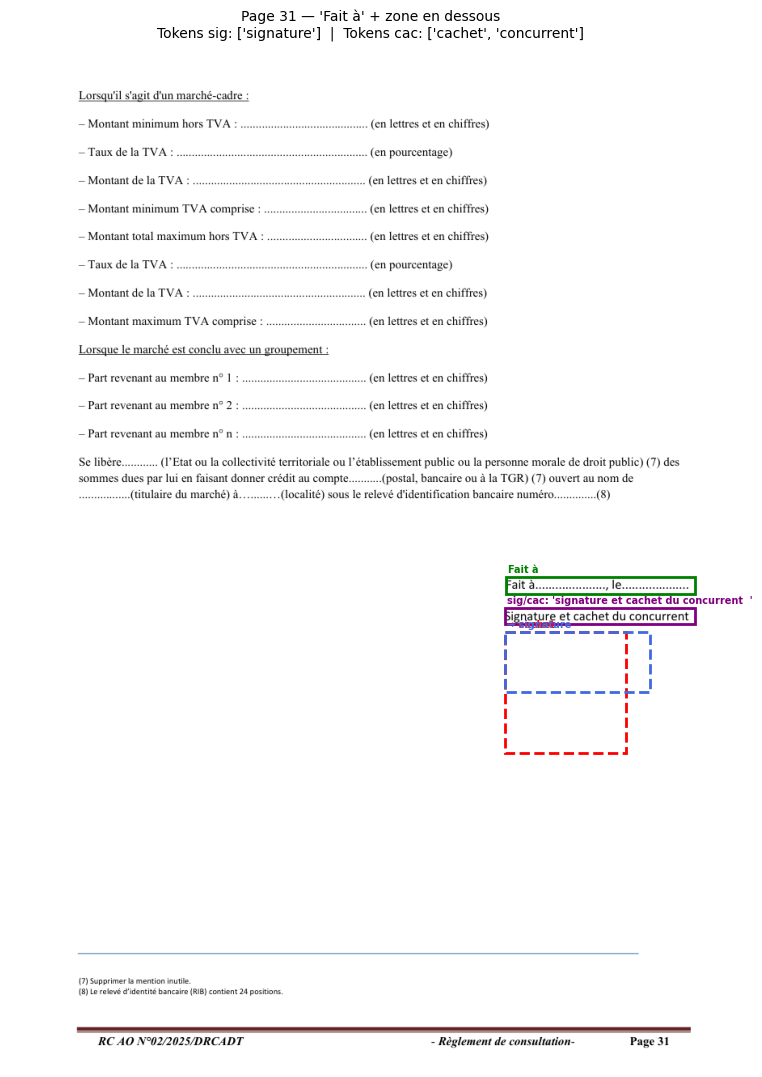

In [36]:
def page_to_image(page, zoom=1.5):
    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
    return np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)


def draw_rect_on_ax(ax, rect, zoom, color, label, linestyle="-", linewidth=2):
    x = rect.x0 * zoom
    y = rect.y0 * zoom
    w = (rect.x1 - rect.x0) * zoom
    h = (rect.y1 - rect.y0) * zoom
    patch = mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="square,pad=0",
        linewidth=linewidth, edgecolor=color, facecolor="none",
        linestyle=linestyle,
    )
    ax.add_patch(patch)
    ax.text(x + 2, y - 5, label, color=color, fontsize=7, fontweight="bold")


def compute_placement(kw_rect, img_w, img_h, page_h, gap=6):
    """Calcule le rect de placement sous kw_rect (ou au-dessus si débordement)."""
    x0 = kw_rect.x0
    y0 = kw_rect.y1 + gap
    y1 = y0 + img_h
    if y1 > page_h - 10:
        y1 = kw_rect.y0 - gap
        y0 = y1 - img_h
    return fitz.Rect(x0, y0, x0 + img_w, y1)


ZOOM = 1.5
GAP  = 6
doc  = fitz.open(str(PDF_INPUT))
n    = len(doc)

# ── Dernière page : zone sig/cac ──────────────────────────────
last = doc[n - 1]
kw_rect, kw_text, sig_m, cac_m = find_zone_last_page(last)
fait_rect_last, _ = find_fait_a(last)

img = page_to_image(last, ZOOM)
ph  = last.rect.height
fig, ax = plt.subplots(figsize=(8, 11))
ax.imshow(img)
ax.axis("off")

if kw_rect:
    draw_rect_on_ax(ax, kw_rect, ZOOM, "purple", f"header: {kw_text!r}")
    sig_place = compute_placement(kw_rect, SIG_W, SIG_H, ph, GAP)
    cac_place = compute_placement(kw_rect, CAC_W, CAC_H, ph, GAP)
    draw_rect_on_ax(ax, cac_place, ZOOM, "red",       "→ cachet",    linestyle="--")
    draw_rect_on_ax(ax, sig_place, ZOOM, "royalblue", "→ signature", linestyle="--")
    ax.set_title(f"Dernière page (page {n}) — ✅ zone détectée\nTokens sig: {sig_m}  |  Tokens cac: {cac_m}", fontsize=10)
else:
    # Fallback positions
    pw = last.rect.width
    fb_sig = fitz.Rect(pw-SIG_MX-SIG_W, ph-SIG_MY-SIG_H, pw-SIG_MX, ph-SIG_MY)
    fb_cac = fitz.Rect(CAC_MX, ph-CAC_MY-CAC_H, CAC_MX+CAC_W, ph-CAC_MY)
    draw_rect_on_ax(ax, fb_sig, ZOOM, "royalblue", "→ sig fallback", linestyle=":")
    draw_rect_on_ax(ax, fb_cac, ZOOM, "red",       "→ cac fallback", linestyle=":")
    ax.set_title(f"Dernière page (page {n}) — ❌ pas de zone, fallback positions fixes", fontsize=10)

if fait_rect_last:
    draw_rect_on_ax(ax, fait_rect_last, ZOOM, "green", "Fait à")

plt.tight_layout()
plt.show()

# ── Pages précédentes : 'Fait à' + zone en dessous ────────────
for i in range(n - 1):
    fait_rect, _ = find_fait_a(doc[i])
    if fait_rect:
        zone_rect, zone_text, z_sig_m, z_cac_m = find_zone_below(doc[i], fait_rect.y1)
        img = page_to_image(doc[i], ZOOM)
        fig, ax = plt.subplots(figsize=(8, 11))
        ax.imshow(img)
        ax.axis("off")
        draw_rect_on_ax(ax, fait_rect, ZOOM, "green", "Fait à")
        if zone_rect:
            draw_rect_on_ax(ax, zone_rect, ZOOM, "purple", f"sig/cac: {zone_text!r}")
            sig_place = compute_placement(zone_rect, SIG_W, SIG_H, doc[i].rect.height, GAP)
            cac_place = compute_placement(zone_rect, CAC_W, CAC_H, doc[i].rect.height, GAP)
            draw_rect_on_ax(ax, cac_place, ZOOM, "red",       "→ cachet",    linestyle="--")
            draw_rect_on_ax(ax, sig_place, ZOOM, "royalblue", "→ signature", linestyle="--")
            ax.set_title(f"Page {i+1} — 'Fait à' + zone en dessous\nTokens sig: {z_sig_m}  |  Tokens cac: {z_cac_m}", fontsize=10)
        else:
            ax.set_title(f"Page {i+1} — 'Fait à' détecté, pas de zone sig/cac en dessous", fontsize=10)
        plt.tight_layout()
        plt.show()

doc.close()

## 5. Application complète — signature + cachet + 'Fait à'

In [37]:
def make_default_signature():
    doc = fitz.open()
    page = doc.new_page(width=200, height=58)
    page.draw_rect(fitz.Rect(3, 3, 197, 55), color=(0.42, 0.2, 0.75), width=1.5)
    page.insert_text(fitz.Point(10, 37), "Signé électroniquement", fontsize=11, color=(0.42, 0.2, 0.75))
    pix = page.get_pixmap(alpha=False)
    data = pix.tobytes("png")
    doc.close()
    return data

def make_default_cachet():
    doc = fitz.open()
    page = doc.new_page(width=110, height=110)
    page.draw_circle(fitz.Point(55, 55), 50, color=(0.42, 0.2, 0.75), width=2.5)
    page.insert_text(fitz.Point(20, 61), "CACHET", fontsize=14, color=(0.42, 0.2, 0.75))
    pix = page.get_pixmap(alpha=False)
    data = pix.tobytes("png")
    doc.close()
    return data


sig_bytes = SIGNATURE.read_bytes() if SIGNATURE.exists() else make_default_signature()
cac_bytes = CACHET.read_bytes()    if CACHET.exists()    else make_default_cachet()
print(f"Signature : {'personnalisée'   if SIGNATURE.exists() else 'défaut générée'}")
print(f"Cachet    : {'personnalisé'    if CACHET.exists()    else 'défaut généré'}")


def fill_fait_a(page, lieu, date_str):
    if not lieu and not date_str:
        return None
    rect, fontsize = find_fait_a(page)
    if rect is None:
        return None
    page.draw_rect(
        fitz.Rect(rect.x0, rect.y0 - 2, page.rect.width - 15, rect.y1 + 2),
        color=(1,1,1), fill=(1,1,1)
    )
    text = "Fait \u00e0"
    if lieu:     text += f" {lieu}"
    if date_str: text += f", le {date_str}"
    page.insert_text(fitz.Point(rect.x0, rect.y1 - 1), text, fontsize=fontsize, color=(0,0,0))
    return rect


def place_image_below(page, kw_rect, image_bytes, img_w, img_h, gap=6):
    ph = page.rect.height
    x0 = kw_rect.x0
    y0 = kw_rect.y1 + gap
    y1 = y0 + img_h
    if y1 > ph - 10:
        y1 = kw_rect.y0 - gap
        y0 = y1 - img_h
    page.insert_image(fitz.Rect(x0, y0, x0 + img_w, y1), stream=image_bytes, keep_proportion=True)


# ── Traitement — même logique que signing_service.py ─────────
doc = fitz.open(str(PDF_INPUT))
n_pages = len(doc)

last_kw_rect, last_kw_text, _, _ = find_zone_last_page(doc[n_pages - 1])
zone_label = repr(last_kw_text) if last_kw_rect else 'non trouvée → fallback'
print(f"Zone détectée sur dernière page : {zone_label}")
print()

for i, page in enumerate(doc):
    pw, ph  = page.rect.width, page.rect.height
    is_last = (i == n_pages - 1)

    fait_rect, _ = find_fait_a(page)
    fill_fait_a(page, LIEU, DATE_STR)
    if fait_rect:
        print(f"  Page {i+1} : 'Fait à' rempli ✓")

    if fait_rect is not None:
        zone_rect, zone_text, _, _ = find_zone_below(page, fait_rect.y1)
        if zone_rect is not None:
            place_image_below(page, zone_rect, cac_bytes, CAC_W, CAC_H)
            place_image_below(page, zone_rect, sig_bytes, SIG_W, SIG_H)
            print(f"  Page {i+1} : cachet + signature à la zone '{zone_text}' ✓")
        else:
            print(f"  Page {i+1} : 'Fait à' présent, aucune zone sig/cac en dessous")

    elif is_last:
        if last_kw_rect is not None:
            place_image_below(page, last_kw_rect, cac_bytes, CAC_W, CAC_H)
            place_image_below(page, last_kw_rect, sig_bytes, SIG_W, SIG_H)
            print(f"  Page {i+1} : cachet + signature à la zone '{last_kw_text}' ✓")
        else:
            # Fallback cachet uniquement
            page.insert_image(
                fitz.Rect(CAC_MX, ph-CAC_MY-CAC_H, CAC_MX+CAC_W, ph-CAC_MY),
                stream=cac_bytes, keep_proportion=True
            )
            print(f"  Page {i+1} : cachet fallback bas-gauche ✓")

    # Signature en bas à droite sur TOUTES les pages (paraphe)
    page.insert_image(
        fitz.Rect(pw-SIG_MX-SIG_W, ph-SIG_MY-SIG_H, pw-SIG_MX, ph-SIG_MY),
        stream=sig_bytes, keep_proportion=True
    )
    print(f"  Page {i+1} : signature paraphe bas-droite ✓")

PDF_OUTPUT.parent.mkdir(exist_ok=True)
doc.save(str(PDF_OUTPUT))
doc.close()
print(f"\n✓ PDF signé sauvegardé : {PDF_OUTPUT}")

Signature : personnalisée
Cachet    : personnalisé
Zone détectée sur dernière page : '(signature et cachet du concurrent) '

  Page 1 : signature paraphe bas-droite ✓
  Page 2 : signature paraphe bas-droite ✓
  Page 3 : signature paraphe bas-droite ✓
  Page 4 : signature paraphe bas-droite ✓
  Page 5 : signature paraphe bas-droite ✓
  Page 6 : signature paraphe bas-droite ✓
  Page 7 : signature paraphe bas-droite ✓
  Page 8 : signature paraphe bas-droite ✓
  Page 9 : signature paraphe bas-droite ✓
  Page 10 : signature paraphe bas-droite ✓
  Page 11 : signature paraphe bas-droite ✓
  Page 12 : signature paraphe bas-droite ✓
  Page 13 : signature paraphe bas-droite ✓
  Page 14 : signature paraphe bas-droite ✓
  Page 15 : signature paraphe bas-droite ✓
  Page 16 : signature paraphe bas-droite ✓
  Page 17 : signature paraphe bas-droite ✓
  Page 18 : signature paraphe bas-droite ✓
  Page 19 : signature paraphe bas-droite ✓
  Page 20 : signature paraphe bas-droite ✓
  Page 21 : signature pa

## 6. Aperçu avant / après — 3 dernières pages

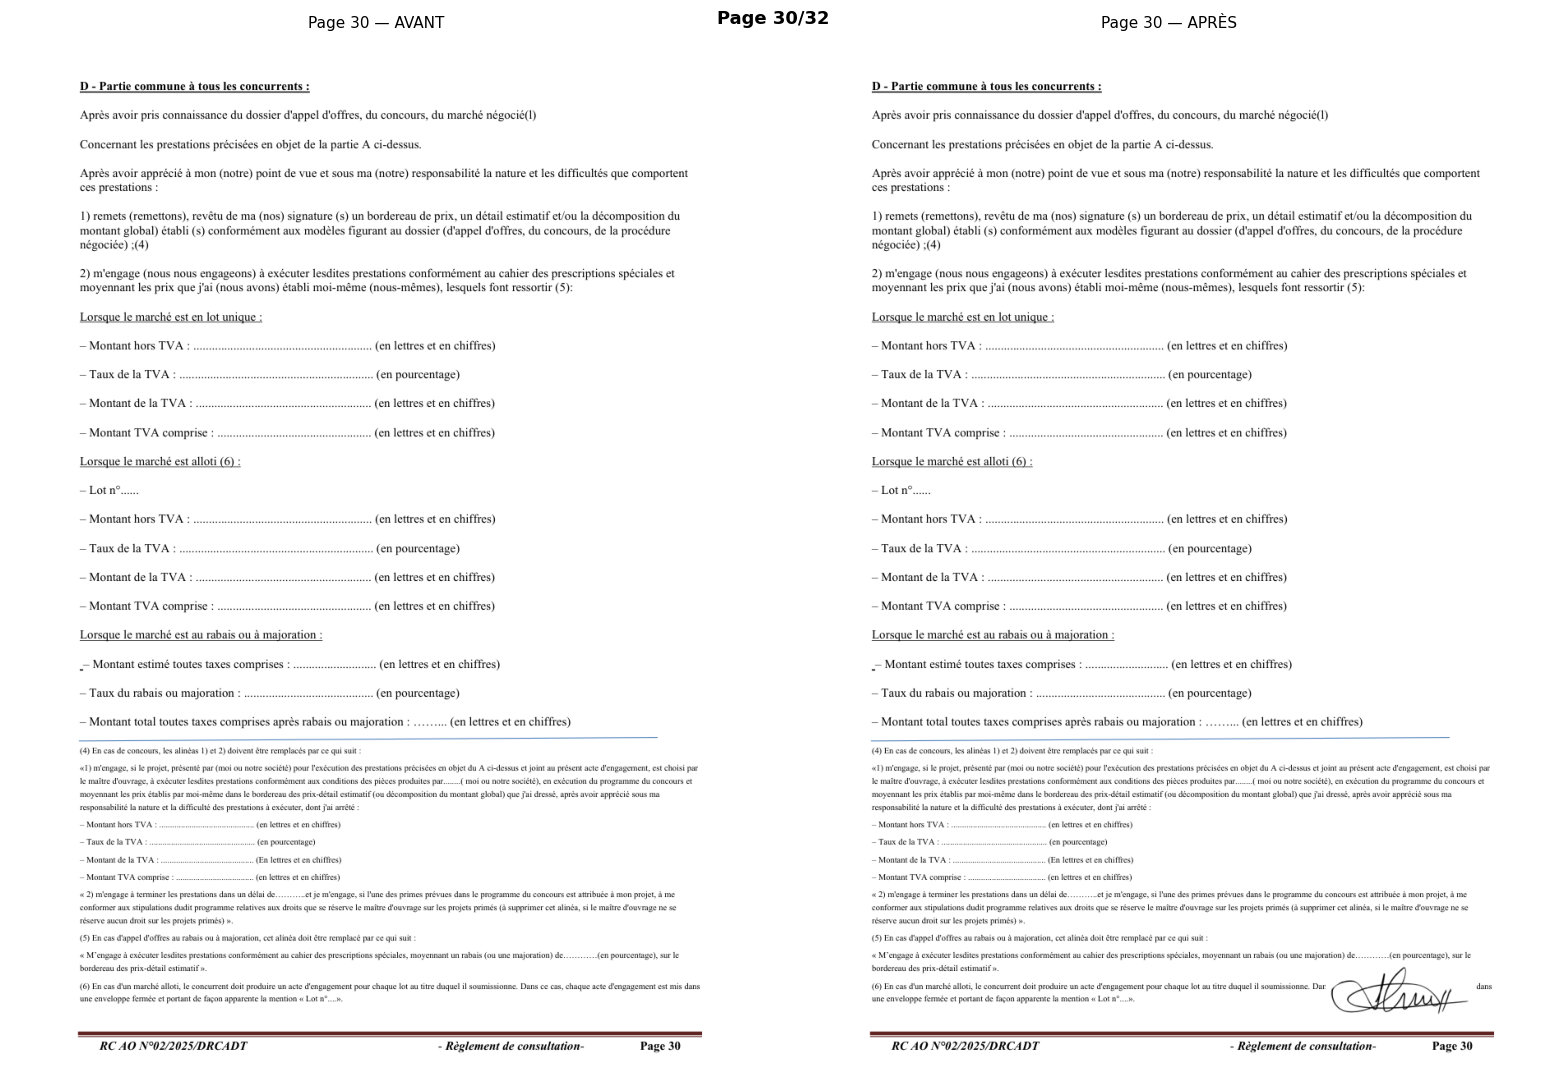

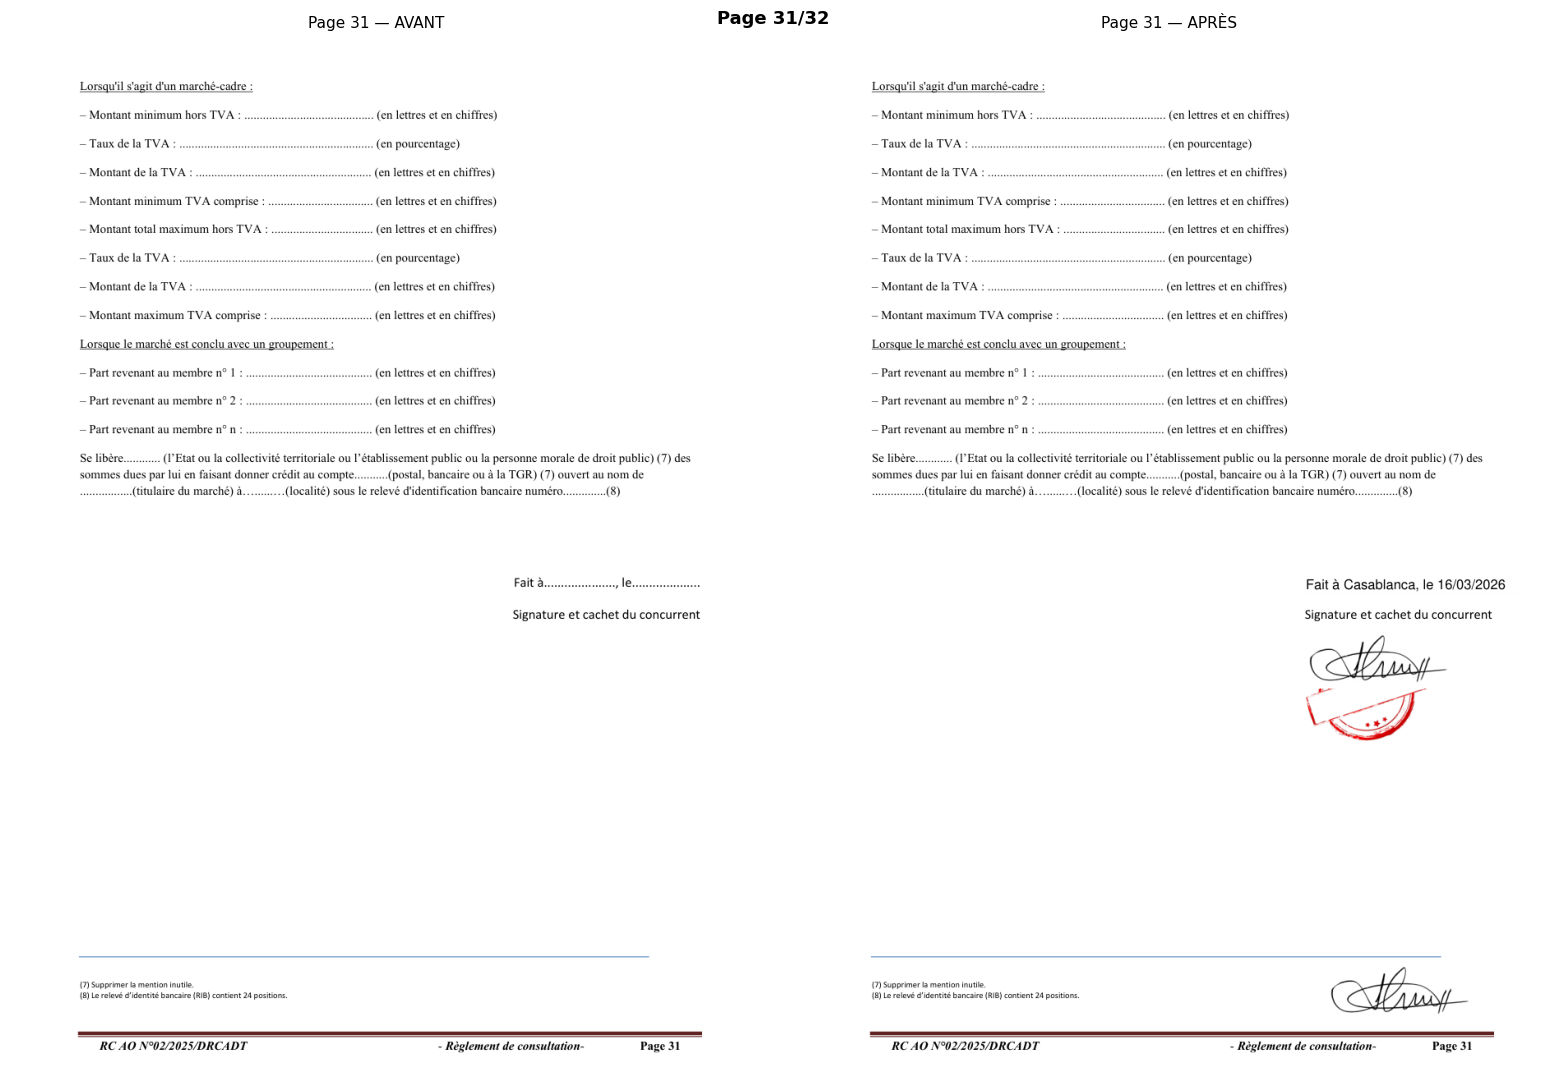

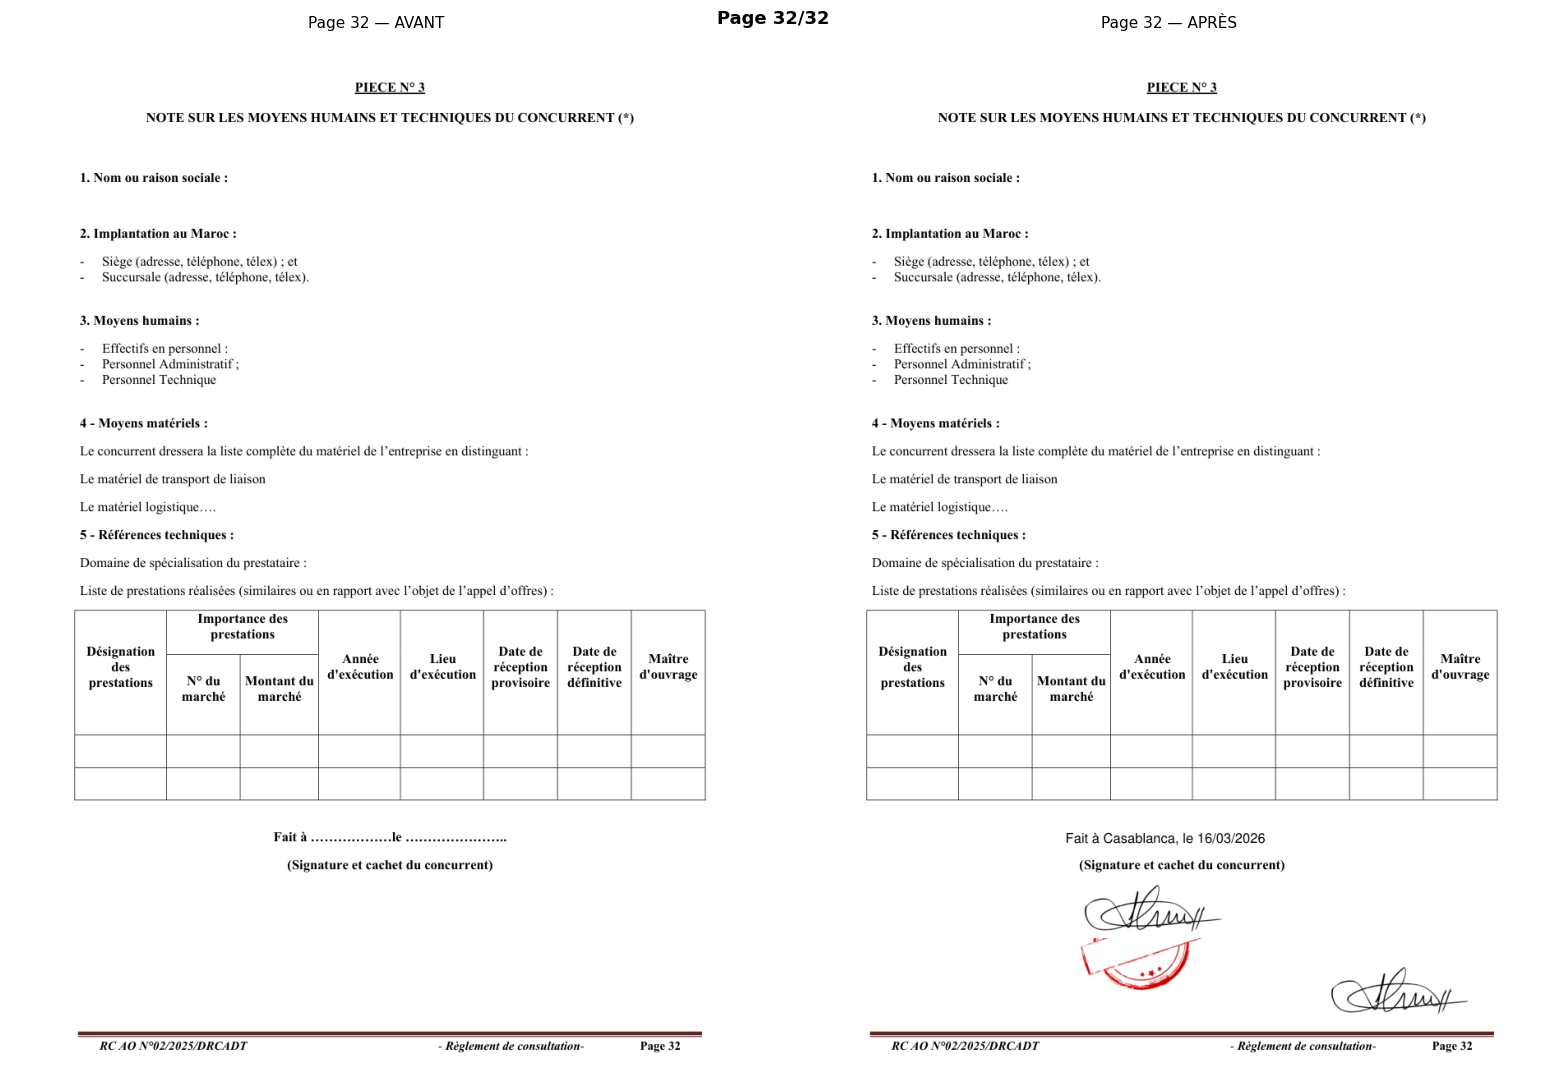

In [38]:
doc_in  = fitz.open(str(PDF_INPUT))
doc_out = fitz.open(str(PDF_OUTPUT))
ZOOM = 1.5

pages_to_show = list(range(max(0, len(doc_out) - 3), len(doc_out)))

for i in pages_to_show:
    img_in  = page_to_image(doc_in[i],  ZOOM)
    img_out = page_to_image(doc_out[i], ZOOM)

    fig, axes = plt.subplots(1, 2, figsize=(16, 11))
    axes[0].imshow(img_in);  axes[0].axis("off"); axes[0].set_title(f"Page {i+1} — AVANT",  fontsize=11)
    axes[1].imshow(img_out); axes[1].axis("off"); axes[1].set_title(f"Page {i+1} — APRÈS", fontsize=11)
    plt.suptitle(f"Page {i+1}/{len(doc_out)}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

doc_in.close()
doc_out.close()